# Task lab work # 5
# Anzhelika Mazurenko
# Group CS32

# 1. Chose the dataset with images (FOR CLASSIFICATION) from sugessted or you could prepare own (find in kaggle or create).
Created own dataset gives additional points in the final mark (100-200 images on each class).

## Links on Datasets
* [Cats Vs Dogs](https://www.tensorflow.org/datasets/catalog/cats_vs_dogs)
* [caltech101: classification of 101 instances](https://www.tensorflow.org/datasets/catalog/caltech101)
* [same as above but with birds](https://www.tensorflow.org/datasets/catalog/caltech_birds2010)
* [with birds v2](https://www.tensorflow.org/datasets/catalog/caltech_birds2011)
* [cars classification](https://www.tensorflow.org/datasets/catalog/cars196)
* [plant disease classification](https://www.tensorflow.org/datasets/catalog/cassava)
* [CIFAR100: classification of 100 instances of types](https://www.tensorflow.org/datasets/catalog/cifar100)
* [Healthy and Unhealthy citrus leaves](https://www.tensorflow.org/datasets/catalog/citrus_leaves)

# 2. Train the same data (but with different data preparation stages) for Convolutional and Fullyconnected NNs.
0. Prepare you data, download into folders, preproces, rescale, etc.
1. Train fullyconnected NN on your selected dataset in the similar manner to example
2. Train convolutional NN on your selected dataset in the similar manner to example

In [15]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D, Dropout

IMG_SIZE = 64
EPOCHS = 10

In [16]:
dataset_raw = tfds.load('citrus_leaves', split='train', as_supervised=True)

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

dataset = dataset_raw.map(preprocess)

In [17]:
images_np, labels_np = [], []

for img, lbl in tfds.as_numpy(dataset):
    images_np.append(img)
    labels_np.append(lbl)

X = np.array(images_np)
y_labels = np.array(labels_np)

In [18]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_labels)
y = to_categorical(y_encoded)
NUM_CLASSES = y.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

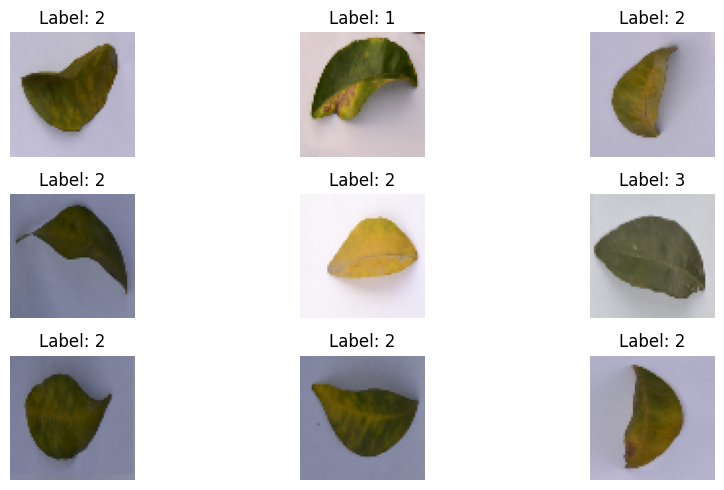

In [19]:
plt.figure(figsize=(10, 5))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i])
    label = encoder.classes_[np.argmax(y_train[i])]
    plt.title(f"Label: {label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [20]:
fc_model = Sequential([
    Flatten(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

fc_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
fc_model.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_test, y_test))

Epoch 1/10


E:\university\3course\2sem\ML\ML_labs\Lab5\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.3398 - loss: 3.3072 - val_accuracy: 0.4824 - val_loss: 2.7407
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3936 - loss: 1.9603 - val_accuracy: 0.6471 - val_loss: 1.2999
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5591 - loss: 1.2066 - val_accuracy: 0.4941 - val_loss: 1.3969
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5201 - loss: 1.1530 - val_accuracy: 0.5176 - val_loss: 0.8992
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6496 - loss: 0.7594 - val_accuracy: 0.5412 - val_loss: 0.9094
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6050 - loss: 0.7812 - val_accuracy: 0.6000 - val_loss: 0.8549
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6686 - loss: 0.7250 - val_accuracy: 0.5647 - val_loss: 0.9317
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6839 - loss: 0.6813 - val_accuracy: 0.6706 - val_loss: 0.

In [21]:
def visualize_predictions(model, X_data, y_true, class_names):
    predictions = model.predict(X_data)
    predicted_classes = np.argmax(predictions, axis=1)
    actual_classes = np.argmax(y_true, axis=1)

    plt.figure(figsize=(12, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_data[i])
        true_label = class_names[actual_classes[i]]
        pred_label = class_names[predicted_classes[i]]
        color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


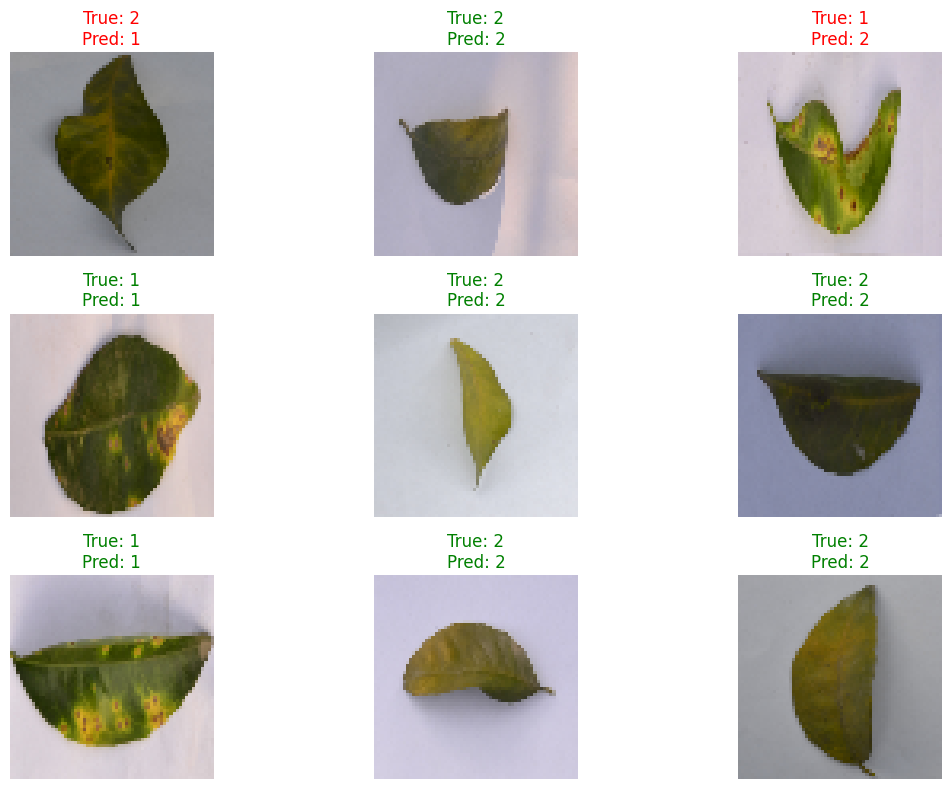

In [22]:
visualize_predictions(fc_model, X_test, y_test, encoder.classes_)

In [23]:
cnn_model = Sequential([
    Conv2D(32, kernel_size=3, activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=2),
    Conv2D(64, kernel_size=3, activation='relu'),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train, y_train, epochs=EPOCHS, validation_data=(X_test, y_test))

Epoch 1/10


E:\university\3course\2sem\ML\ML_labs\Lab5\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 158ms/step - accuracy: 0.4384 - loss: 1.0680 - val_accuracy: 0.6941 - val_loss: 0.8327
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.5680 - loss: 0.8510 - val_accuracy: 0.6824 - val_loss: 0.6312
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6433 - loss: 0.7406 - val_accuracy: 0.7412 - val_loss: 0.5589
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6966 - loss: 0.6764 - val_accuracy: 0.7765 - val_loss: 0.4600
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.8048 - loss: 0.5461 - val_accuracy: 0.8000 - val_loss: 0.4917
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8018 - loss: 0.4901 - val_accuracy: 0.8000 - val_loss: 0.4637
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8121 - loss: 0.4617 - val_accuracy: 0.9294 - val_loss: 0.2754
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.8872 - loss: 0.2977 - val_accuracy: 0.9059 - val_loss: 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


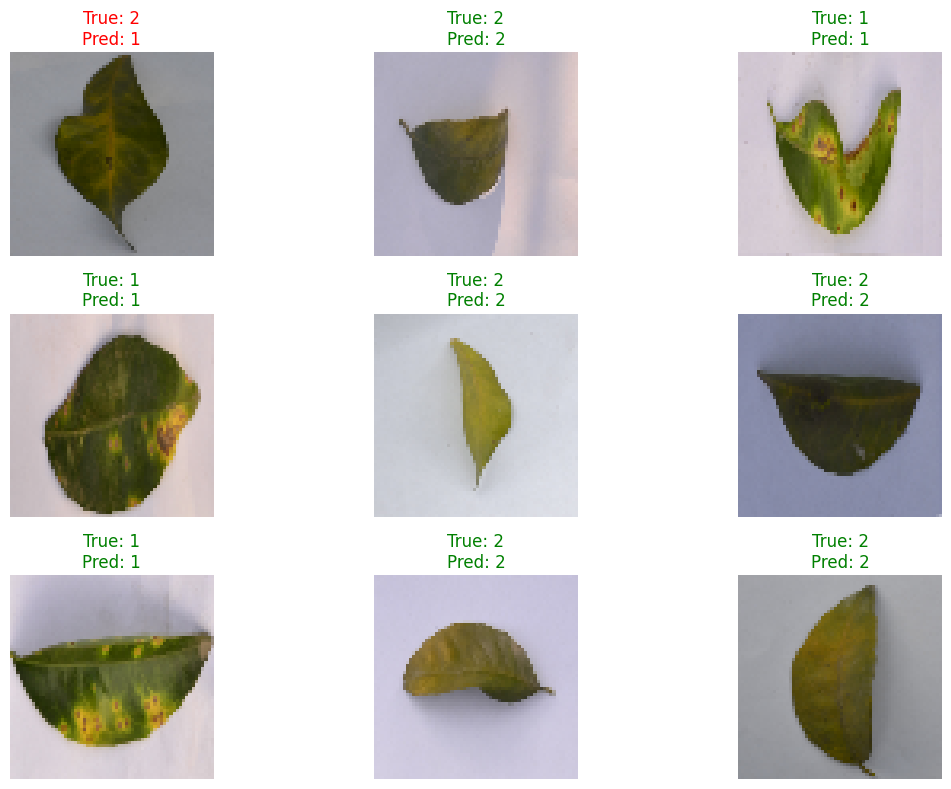

In [24]:
visualize_predictions(cnn_model, X_test, y_test, encoder.classes_)